(information_market_equilibrium)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;"
                width="250px"
                src="https://assets.quantecon.org/img/qe-menubar-logo.svg"
                alt="QuantEcon">
        </a>
</div>
```

# 信息与市场均衡

```{contents} Contents
:depth: 2
```

## 概述

本讲研究关于**价格的信息作用**的两个问题，这两个问题由 {cite:t}`kihlstrom_mirman1975` 提出并回答。

1. *价格何时传递内部信息？*
   - 一位知情的内部人观察到与未知世界状态相关的私有信号，并据此调整需求。
   - 均衡价格随之变动。
   - 在什么条件下，外部观察者可以从均衡价格*推断*出内部人的后验分布？

2. *贝叶斯价格预期会收敛吗？*
   - 在一个平稳的随机交换经济中，一位不知情的观察者利用市场价格的历史和贝叶斯法则来形成关于经济结构的信念，进而形成关于其所诱导的价格分布的信念。
   - 这些预期最终会与一位完全知情的观察者的预期一致吗？

Kihlstrom 和 Mirman 的回答依赖于统计学中的两个经典思想：

- **Blackwell 充分性**：如果知道随机变量 $\tilde{y}$ 就能给出 $\tilde{y}'$ 所包含的关于状态的所有信息，那么就称随机变量 $\tilde{y}$ 相对于某个未知状态对随机变量 $\tilde{y}'$ 是*充分的*。
- **贝叶斯一致性**：随着样本增长，后验信念会排除那些隐含错误**价格分布**的模型，因此即使无法从价格中识别出结构，后验对真实**简约形式**的质量仍会收敛到一。

{cite:t}`kihlstrom_mirman1975` 的重要发现是：

- 均衡价格能够传递内部信息，*当且仅当*从内部人后验分布到均衡价格的映射在信号实际可能产生的后验集合上是一一对应的。
  - 对于两状态的情形（$S = 2$），当知情者的效用是位似的，且替代弹性处处小于一或处处大于一时，可逆性成立。
- 在动态经济中，随着信息的累积，贝叶斯价格预期会收敛到**理性预期**，即使无法仅从价格中识别出深层结构。

```{note}
{cite:t}`kihlstrom_mirman1975` 以细致的计量经济学家所采用的方式使用了"简约形式"和"结构"模型这两个术语。

简约形式模型和结构模型成对出现。

对于每一个结构或结构模型，都存在一个简约形式，或者一组对应于不同可能回归的简约形式。
```

本讲的组织结构如下。

1. 建立静态两商品模型并定义均衡。
2. 陈述价格揭示定理和可逆性条件。
3. 用 CES 和科布-道格拉斯偏好的数值例子来说明可逆性及其失效。
4. 引入动态随机经济并推导贝叶斯收敛结果。
5. 模拟从价格观测中进行的贝叶斯学习。

本讲以 {doc}`blackwell_kihlstrom` 和 {doc}`likelihood_bayes` 中的思想为基础。

我们首先导入一些 Python 包。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

## 设定

### 偏好、禀赋与未知状态

该经济有两种商品。

商品 2 是计价商品（价格标准化为 1）。

商品 1 以价格 $p > 0$ 交易。

一个未知参数 $\bar{a}$ 影响商品 1 的价值。

代理人 $i$ 从一束商品 $(x_1^i, x_2^i)$ 中获得的期望效用为

$$
U^i(x_1^i, x_2^i)
  = \sum_{s=1}^{S} u^i(a_s x_1^i,\, x_2^i)\, P^i(\bar{a} = a_s),
$$

其中 $P^i$ 是代理人 $i$ 在有限状态空间 $A = \{a_1, \ldots, a_S\}$ 上的主观概率分布。

每个代理人初始拥有商品 2 的禀赋 $w^i$ 以及代表性企业的一份份额 $\theta^i$。

在该论文的形式模型中，一家企业根据 $y_1 = f(y_2)$（其中 $f' < 0$）将商品 2 转化为商品 1，并选择生产以最大化

$$
\pi(p) = \max_{y_2 \leq 0} \{p f(y_2) + y_2\}.
$$

企业的利润 $\pi$ 随后按份额 $\theta^i$ 分配给家庭。

代理人 $i$ 的预算约束是

$$
p x_1^i + x_2^i = w^i + \theta^i \pi.
$$

代理人在预算约束下最大化期望效用。

**竞争均衡**是一个能同时出清两个市场的价格 $\hat{p}$。

在所维持的凸性假设下，均衡存在，并且遵循 {cite:t}`kihlstrom_mirman1975`，我们假设均衡价格是唯一的，从而可以将 $\hat p = p(\mu)$ 写作知情代理人后验的一个良好定义的函数。

在接下来的大部分内容中，生产方面只通过所诱导的均衡价格映射发挥作用，因此当我们转向数值说明时，我们将略去生产，并使用纯交换/投资组合的解释，以保持计算的透明性。

### 知情代理人的问题

假设**代理人 1**（内部人）在交易前观察到一个与 $\bar{a}$ 相关的私有信号 $\tilde{y}$，其中 $\tilde{y}$ 取值于有限集合 $Y$。

在信号到达之前，代理人 1 拥有先验信念 $\mu_0 = P^1$。

在观察到 $\tilde{y} = y$ 后，代理人 1 通过贝叶斯法则更新到**后验** $\mu_y = (\mu_{y1}, \ldots, \mu_{yS})$：

$$
\mu_{ys} = P(\bar{a} = a_s \mid \tilde{y} = y).
$$

由于代理人 1 的需求依赖于 $\mu_y$，新的均衡价格满足

$$
\hat{p} = p(\mu_y).
$$

看到 $\hat{p}$ 但看不到 $\tilde{y}$ 的外部观察者可以尝试从价格中*倒推*出内部人的后验。

定义已实现后验的集合

$$
M = \{\mu_y : y \in Y,\; P(\tilde y = y) > 0\}.
$$

关键问题是映射 $\mu \mapsto p(\mu)$ 在 $M$ 上是否一一对应。

为了回答这个问题，我们现在将"价格中的信息"翻译成 Blackwell 的充分性语言。

(price_revelation_theorem)=
## 价格揭示

### Blackwell 充分性

如果观察均衡价格与直接观察信号 $\tilde{y}$ 对 $\bar{a}$ 的信息量相同，那么价格变量 $p(\mu_{\tilde{y}})$ 就*准确地传递*了内部人的私有信息。

在 Blackwell 的语言中（{cite:t}`blackwell1951` 和 {cite:t}`blackwell1953`），这意味着 $p(\mu_{\tilde{y}})$ 对 $\tilde{y}$ 是**充分的**。

```{prf:definition} 充分性
:label: ime_def_sufficiency

如果存在一个**独立于** $\bar{a}$ 的条件分布 $P(y' \mid y)$，使得

$$
\phi'_a(y') = \sum_{y \in Y} P(y' \mid y)\, \phi_a(y)
\quad \text{对所有 } a \text{ 和所有 } y',
$$

其中 $\phi_a(y) = P(\tilde{y} = y \mid \bar{a} = a)$，那么随机变量 $\tilde{y}$ 相对于 $\bar{a}$ 对 $\tilde{y}'$ 是*充分的*。

因此，一旦知道 $\tilde{y}$，$\tilde{y}'$ 就不再提供关于 $\bar{a}$ 的额外信息。
```

{cite:t}`kihlstrom_mirman1975` 证明了

```{prf:lemma} 后验充分性
:label: ime_lemma_posterior_sufficiency

后验分布 $\mu_{\tilde{y}}$ 是 $\tilde{y}$ 的一个充分统计量。
```

```{prf:proof} （概要）
后验 $\mu_{\tilde{y}}$ 满足

$$
P(\bar{a} = a_s \mid \mu_{\tilde{y}} = \mu_y,\; \tilde{y} = y) = \mu_{ys}
  = P(\bar{a} = a_s \mid \mu_{\tilde{y}} = \mu_y).
$$

该恒等式表明，一旦知道后验，以原始信号 $\tilde y$ 为条件并不会改变关于 $\bar a$ 的信念。

等价地，给定 $\mu_{\tilde y}$ 时 $\tilde y$ 的条件分布独立于 $\bar a$，因此 $\mu_{\tilde y}$ 在 Blackwell 意义下对 $\tilde y$ 是充分的。
```

现在让我们考虑从信念到价格的映射。

```{prf:theorem} 价格揭示
:label: ime_theorem_price_revelation

在上述模型中，价格随机变量 $p(\mu_{\tilde{y}})$ 对随机变量 $\tilde{y}$ 是充分的，当且仅当函数 $p(P^1)$ 在价格集合

$$
\mathcal{P} = \Bigl\{\, p(\mu_y) : y \in Y,\;
  P(\tilde{y} = y) = \sum_{a \in A} \phi_a(y)\,\mu_0(a) > 0 \Bigr\}
$$

上是可逆的。
```

其逻辑是

$$
\tilde y \quad \longrightarrow \quad \mu_{\tilde y} \quad \longrightarrow \quad
p(\mu_{\tilde y}).
$$

根据 {prf:ref}`ime_lemma_posterior_sufficiency`，第一个箭头没有损失关于 $\bar a$ 的信息，而该定理询问的是第二个箭头何时也没有损失信息。

证明分为两部分。

如果 $p(\cdot)$ 在 $M$ 上是一一对应的，那么观察价格就等价于观察后验本身，因为

$$
P(\mu_{\tilde y} = \mu \mid p(\mu_{\tilde y}) = p)
= \begin{cases}
1 & \text{如果 } \mu = p^{-1}(p), \\
0 & \text{否则。}
\end{cases}
$$

这个条件分布独立于状态，因此价格对后验是充分的；结合 {prf:ref}`ime_lemma_posterior_sufficiency`，价格因而对信号是充分的。

反之，如果 $M$ 中两个不同的后验产生了相同的价格，那么价格的观察者就无法分辨发生的是哪个后验，而该论文正式表明，在这种情况下，给定价格时后验的条件分布将依赖于状态，因此价格不可能是充分的。

在转向可逆性本身之前，记住该论文所强调的两种经济解释是有帮助的。

### 两种解释

#### 股票市场中的内幕交易

商品 1 是一种具有随机回报 $\bar{a}$ 的风险资产；商品 2 是"货币"。

内部人的需求揭示了关于回报的私有信息。

如果可逆性条件成立，外部观察者就可以从均衡股票价格中读出内部人的后验分布——即内部人信号所携带的关于 $\bar a$ 的有用信息。

#### 价格作为质量信号

商品 1 的质量 $\bar{a}$ 是不确定的。

有经验的消费者（曾试用过该商品）观察到一个与质量相关的信号，并据此购买。

不知情的消费者只要可逆性成立，就可以从市场价格推断质量。

(invertibility_conditions)=
## 可逆性与替代弹性

信念到价格的映射何时不可逆？

{prf:ref}`ime_theorem_invertibility_conditions` 表明，对于一个两状态经济（$S = 2$），答案取决于代理人 1 的效用函数的**替代弹性** $\sigma$。

在陈述该定理之前，先看看该论文论证中的两个中间步骤是有帮助的。

```{prf:lemma} 相同价格意味着相同配置
:label: ime_lemma_same_price_same_allocation

假设 $u^i$ 具有连续的一阶偏导数，且 $u^i$ 是拟凹的。

设 $p \in \mathcal{P}$。

如果存在 $M$ 中的两个测度 $\mu^*$ 和 $\mu'$，使得 $p(\mu^*, P^2, \ldots, P^n) = p(\mu', P^2, \ldots, P^n) = p$，那么

$$
x^i(\mu^*, P^2, \ldots, P^n) = x^i(\mu', P^2, \ldots, P^n), \quad
i = 1, \ldots, n.
$$
```

固定除代理人 1 之外所有代理人的信念。

该引理表明，如果代理人 1 的两个后验信念 $\mu^*$ 和 $\mu'$ 都支持相同的均衡价格 $p$，那么它们对每一位交易者都支持相同的均衡配置。

其直觉是，当价格不变时，不知情交易者的需求也不变，因此市场出清迫使知情代理人的商品束也保持不变。

该引理使我们能够将知情代理人的均衡商品束定义为价格的一个函数：

$$
x(p) = (x_1(p), x_2(p)).
$$

在全文中，$u^i_j$ 表示 $u^i$ 对其第 $j$ 个参数的偏导数。

每当知情代理人对两种商品都消费正的数量时，在后验 $\mu$ 下 $x(p)$ 的最优性给出了内部一阶条件

$$
p = \frac{\sum_{s=1}^S a_s u_1^1(a_s x_1(p), x_2(p))\, \mu(a_s)}
         {\sum_{s=1}^S u_2^1(a_s x_1(p), x_2(p))\, \mu(a_s)}.
$$

对于一个固定的价格 $p$，商品束 $x(p)$ 也是固定的，因此可逆性归结为这个方程是否有唯一的后验 $\mu$。

```{prf:lemma} 给定价格下的唯一后验
:label: ime_lemma_unique_posterior

假设 $u^1$ 的一阶偏导数存在，且 $u^1$ 是拟凹的。

同时假设代理人 1 总是消费两种商品的正数量。

那么，如果对每个 $p \in \mathcal{P}$ 都存在唯一的概率测度 $\mu \in M$ 使得

$$
\frac{\sum_{s=1}^S a_s\, u^1_1(a_s x_1(p), x_2(p))\, \mu(a_s)}
     {\sum_{s=1}^S u^1_2(a_s x_1(p), x_2(p))\, \mu(a_s)} = p,
$$

那么 $p(P^1)$ 在 $\mathcal{P}$ 上是可逆的。
```

如果两个不同的后验给出相同的价格，那么根据 {prf:ref}`ime_lemma_same_price_same_allocation`，它们将共享相同的商品束 $x(p)$，这与在该价格下求解一阶条件的后验的唯一性相矛盾。

### 两状态一阶条件

当 $S = 2$ 且 $\mu = (q,\, 1-q)$ 时，定义

$$
\alpha_s(p) = a_s\, u^1_1(a_s x_1(p),\, x_2(p)), \qquad
\beta_s(p)  = u^1_2(a_s x_1(p),\, x_2(p)), \qquad s = 1, 2.
$$

那么一阶条件变为

$$
p = \frac{\alpha_1(p)\, q + \alpha_2(p)\, (1-q)}
         {\beta_1(p)\, q + \beta_2(p)\, (1-q)}.
$$

在固定价格 $p$ 处，数量 $\alpha_s(p)$ 和 $\beta_s(p)$ 是常数，因此后验的唯一性与求解此方程的标量 $q$ 的唯一性是相同的。

```{prf:theorem} 可逆性条件
:label: ime_theorem_invertibility_conditions

假设 $u^1$ 的一阶偏导数存在，且 $u^1$ 是拟凹且位似的。

同时假设知情代理人在所有均衡配置中总是消费两种商品的正数量。

如果 $S = 2$ 且 $u^1$ 的替代弹性始终小于一或始终大于一，那么 $p(P^1)$ 在 $\mathcal{P}$ 上是可逆的。

如果 $u^1$ 是科布-道格拉斯型的（替代弹性恒等于一），那么 $p(P^1)$ 在 $\mathcal{P}$ 上是常数。
```

当 $\sigma = 1$ 时，收入效应和替代效应恰好相互抵消，因此代理人 1 对商品 1 的需求不会对关于 $\bar{a}$ 的信念变化做出反应。

由于需求不变，市场出清价格也不变，价格因而不揭示内部人信号的任何信息。

### CES 效用

为具体起见，我们使用一个采用**常替代弹性**（CES）效用函数的简化例子

$$
u(c_1, c_2) = \bigl(c_1^{\rho} + c_2^{\rho}\bigr)^{1/\rho}, \qquad \rho \in
(-\infty,0) \cup (0,1),
$$

其替代弹性为 $\sigma = 1/(1-\rho)$。

- $\rho \to 0$：科布-道格拉斯（$\sigma = 1$）。
- $\rho < 0$：$\sigma < 1$（互补品）。
- $0 < \rho < 1$：$\sigma > 1$（替代品）。

相关的偏导数为

$$
u_1(c_1,c_2) = \bigl(c_1^\rho + c_2^\rho\bigr)^{1/\rho - 1}\, c_1^{\rho-1},
\qquad
u_2(c_1,c_2) = \bigl(c_1^\rho + c_2^\rho\bigr)^{1/\rho - 1}\, c_2^{\rho-1}.
$$

这个 CES 例子只是一个说明，因为定理本身涵盖任何弹性处处大于一或处处小于一的位似效用。

有了这个例子，我们就可以直接将均衡价格计算为后验的函数。

### 均衡价格作为后验的函数

我们将代理人 1 视为*唯一*的知情交易者，他在均衡时吸收一单位的商品 1（即 $x_1 = 1$）。

令 $W_1 = w^1 + \theta^1 \pi$ 表示代理人 1 的总财富（禀赋加利润份额）。

代理人 1 的预算约束因而简化为 $x_2 = W_1 - p$，均衡价格是满足一阶条件的唯一的 $p \in (0, W_1)$

$$
p \bigl[q\, u_2(a_1,\, W_1-p) + (1-q)\, u_2(a_2,\, W_1-p)\bigr]
= q\, a_1\, u_1(a_1,\, W_1-p) + (1-q)\, a_2\, u_1(a_2,\, W_1-p).
$$

对于科布-道格拉斯效用（$\sigma = 1$），一阶条件变为 $p = W_1 - p$，得到 $p^* = W_1/2$，与后验 $q$ 无关，这证实了在科布-道格拉斯情形下没有信息通过价格传递。

我们在下面数值计算一阶条件。

In [2]:
def ces_derivatives(c1, c2, ρ):
    """
    返回 CES 边际效用。

    在 rho = 0 附近使用科布-道格拉斯极限。
    """
    if abs(ρ) < 1e-4:
        u1 = 0.5 * np.sqrt(c2 / c1)
        u2 = 0.5 * np.sqrt(c1 / c2)
    else:
        common = (c1**ρ + c2**ρ)**(1 / ρ - 1)
        u1 = common * c1**(ρ - 1)
        u2 = common * c2**(ρ - 1)
    return u1, u2


def eq_price(q, a1, a2, W1, ρ):
    """返回后验 q 对应的均衡价格。"""
    def residual(p):
        x2 = W1 - p
        u1_s1, u2_s1 = ces_derivatives(a1, x2, ρ)
        u1_s2, u2_s2 = ces_derivatives(a2, x2, ρ)
        lhs = p * (q * u2_s1 + (1 - q) * u2_s2)
        rhs = q * a1 * u1_s1 + (1 - q) * a2 * u1_s2
        return lhs - rhs

    try:
        return brentq(residual, 1e-6, W1 - 1e-6, xtol=1e-10)
    except ValueError:
        return np.nan

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


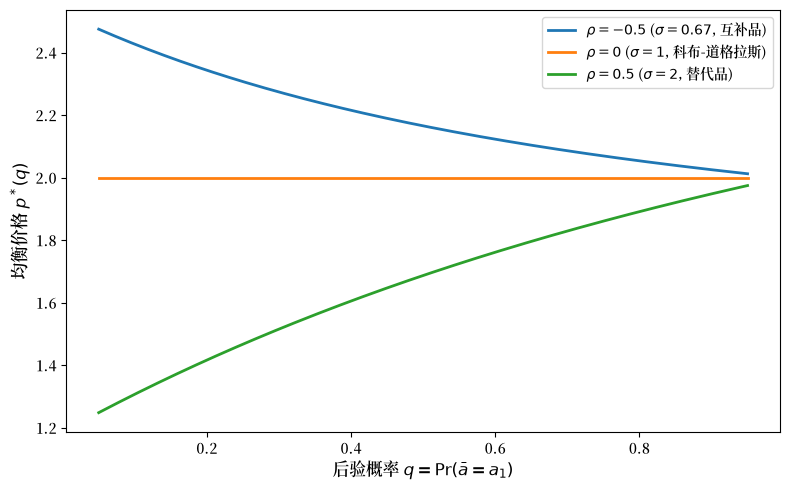

In [3]:
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

a1, a2 = 2.0, 0.5     # 状态值 (a1 > a2)
W1 = 4.0

q_grid = np.linspace(0.05, 0.95, 200)

ρ_values = [-0.5, 0.0, 0.5]
ρ_labels = [
    r"$\rho = -0.5$ ($\sigma = 0.67$, 互补品)",
    r"$\rho = 0$ ($\sigma = 1$, 科布-道格拉斯)",
    r"$\rho = 0.5$ ($\sigma = 2$, 替代品)",
]

fig, ax = plt.subplots(figsize=(8, 5))

for ρ, label in zip(ρ_values, ρ_labels):
    prices = [eq_price(q, a1, a2, W1, ρ) for q in q_grid]
    ax.plot(q_grid, prices, label=label, lw=2)

ax.set_xlabel(r"后验概率 $q = \Pr(\bar{a} = a_1)$", fontsize=12)
ax.set_ylabel("均衡价格 $p^*(q)$", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

该图证实了 {prf:ref}`ime_theorem_invertibility_conditions`。

对于 $\sigma \neq 1$ 的 CES，均衡价格在 $q$ 上是严格单调的。

因此，知道均衡映射 $p^*(\cdot)$ 的外部观察者可以唯一地反转价格以恢复 $q$，故内部信息被完全传递。

对于科布-道格拉斯（$\sigma = 1$），价格在 $q$ 上是平坦的，因此信息永远不会通过市场传递。

In [4]:
p_cd = [eq_price(q, a1, a2, W1, ρ=0.0) for q in q_grid]

print(f"Cobb-Douglas (rho=0): min p* = {min(p_cd):.6f}, "
      f"max p* = {max(p_cd):.6f}, "
      f"range = {max(p_cd)-min(p_cd):.2e}")
print(f"Analytical CD price  = W1/2 = {W1/2:.6f}")

Cobb-Douglas (rho=0): min p* = 2.000000, max p* = 2.000000, range = 8.88e-16
Analytical CD price  = W1/2 = 2.000000


每一项都恰好等于 $W_1/2 = 2.0$，从解析上证实了科布-道格拉斯均衡价格与 $q$ 以及状态值 $a_1, a_2$ 无关。

数值图显示了单调性，下一小节将这个模式与 {prf:ref}`ime_theorem_invertibility_conditions` 的证明联系起来。

(price_monotonicity)=
### 为什么单调性取决于 $\sigma$

固定一个价格 $p$，并将 $\alpha_s(p)$ 和 $\beta_s(p)$ 视为常数。

两状态一阶条件的右侧

$$
\frac{\alpha_1(p)\, q + \alpha_2(p)\, (1-q)}
     {\beta_1(p)\, q + \beta_2(p)\, (1-q)}
$$

因而是 $q$ 单独的函数，其导数为

$$
\frac{\partial}{\partial q}
\frac{\alpha_1 q + \alpha_2 (1-q)}
     {\beta_1 q + \beta_2 (1-q)}
= \frac{\alpha_1 \beta_2 - \alpha_2 \beta_1}
       {\bigl[\beta_1 q + \beta_2 (1-q)\bigr]^2}.
$$

因此符号由 $\alpha_1 \beta_2 - \alpha_2 \beta_1$ 决定，如果这个符号是恒定的，那么对每个固定价格，最多有一个与一阶条件相容的后验权重 $q$，这正是 {prf:ref}`ime_theorem_invertibility_conditions` 所要求的。

利用

$$
\frac{\alpha_s}{\beta_s}
  = \frac{a_s\, u_1(a_s x_1, x_2)}{u_2(a_s x_1, x_2)}
  = a_s^{(\sigma-1)/\sigma}\,\Bigl(\frac{x_2}{x_1}\Bigr)^{1/\sigma},
$$

可以证明

$$
\frac{\partial}{\partial a}\,\frac{\alpha}{\beta}
  = \frac{(\sigma - 1)}{\sigma}\, a^{-1/\sigma}\,
    \Bigl(\frac{x_2}{x_1}\Bigr)^{1/\sigma}.
$$

对于 CES 设定，当 $\sigma > 1$ 时该导数为正，当 $\sigma < 1$ 时为负，*当 $\sigma = 1$ 时为零*。

换句话说，对于 CES 效用，比率 $\alpha_s / \beta_s$ 随状态值 $a_s$ 单调变化，除非 $\sigma = 1$，这使得固定价格的一阶条件表达式在 $q$ 上单调，进而带来可逆性。

科布-道格拉斯情形下导数消失意味着边际替代率与 $a_s$ 无关，因此知情代理人的需求，进而均衡价格，不会对信念变化做出反应。

让我们将比率 $\alpha_s / \beta_s$ 作为 $a_s$ 的函数，对不同的 $\sigma$ 值进行可视化：

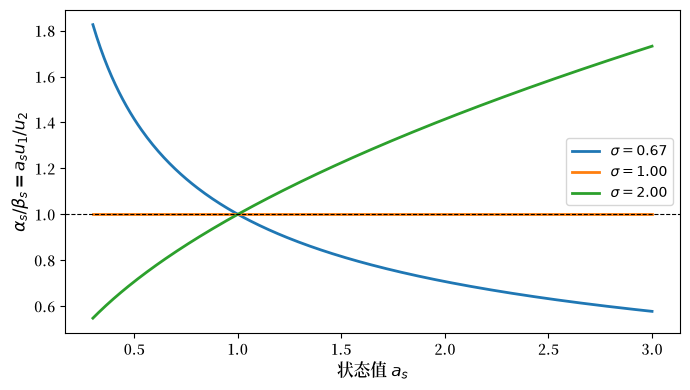

In [5]:
a_vals = np.linspace(0.3, 3.0, 300)
x1_fix, x2_fix = 1.0, 1.0

fig, ax = plt.subplots(figsize=(7, 4))
for ρ in [-0.5, -1e-6, 0.5]:
    σ = 1 / (1 - ρ) if abs(ρ) > 1e-8 else 1.0
    ratios = []
    for a in a_vals:
        u1, u2 = ces_derivatives(a * x1_fix, x2_fix, ρ)
        ratios.append(a * u1 / u2)
    ax.plot(a_vals, ratios, label=rf"$\sigma = {σ:.2f}$", lw=2)

ax.set_xlabel(r"状态值 $a_s$", fontsize=12)
ax.set_ylabel(r"$\alpha_s / \beta_s = a_s u_1 / u_2$", fontsize=12)
ax.axhline(y=1.0, color="black", lw=0.8, ls="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

当 $\sigma = 1$ 时，该比率在所有 $a_s$ 值上都是常数，因此关于状态的信息对边际替代率没有影响。

对于 $\sigma < 1$，该比率在 $a_s$ 上递减，而对于 $\sigma > 1$，它递增，这使得均衡价格在两种情况下都在后验 $q$ 上严格单调。

静态分析询问当前价格是否揭示当前私有信息，而下一节则询问整个价格历史随时间揭示了什么。

(bayesian_price_expectations)=
## 动态经济中的贝叶斯价格预期

我们现在转向 {cite:t}`kihlstrom_mirman1975` 第 3 节所讨论的一个问题。

### 一个随机交换经济

时间是离散的：$t = 1, 2, \ldots$

在每一期 $t$：

1. 消费者 $i$ 收到一个随机禀赋 $\omega_i^t$。
2. 市场开放；竞争价格 $p^t = p(\omega^t)$ 出清所有市场。
3. 消费者进行交易和消费。

禀赋向量 $\{\tilde{\omega}^t\}$ 是**独立同分布**的，其密度为 $f(\omega^t \mid \lambda)$，其中 $\lambda = (\lambda_1, \ldots, \lambda_K)$ 是一个**结构参数向量**（维数为 $K$），它是*固定但未知的*。

$t$ 时刻的均衡价格是 $\omega^t$ 的确定性函数，因此 $\{p^t\}$ 也是独立同分布的。

对于任何可测的价格集合 $P$，令

$$
W(P) = \{\omega^t : p(\omega^t) \in P\}.
$$

那么

$$
P_\lambda(p^t \in P) = P_\lambda(\omega^t \in W(P))
= \int_{W(P)} f(\omega^t \mid \lambda)\, d\omega^t.
$$

所诱导的价格密度记为 $g(p^t \mid \lambda)$。

对于给定的结构 $\lambda$，这个密度是模型的可观测含义，当几个结构隐含相同的密度时，我们将它们归为一个单一的简约形式类。

因此下一个问题是观察者仅从价格数据中能够和不能够推断出关于结构的什么信息。

### 识别问题

由于价格观测仅识别所诱导的价格密度 $g(\cdot \mid \lambda)$，并且由于从结构到简约形式的映射 $\lambda \mapsto g(\cdot \mid \lambda)$ 可能是多对一的，因此价格数据可能只识别一个简约形式类，而不是精确的结构。

特别地，即使有无限的价格数据，也可能无法从 $g(p \mid \lambda)$ 中恢复 $\lambda$。

为了处理这一点，将 $\Lambda$ 划分为等价类 $\mu$，使得当对所有 $p$ 都有 $g(p \mid \lambda) = g(p \mid \lambda')$ 时，$\lambda \in \mu$ 且 $\lambda' \in \mu$。

包含真实 $\lambda$ 的等价类 $\mu$ 是与价格数据相关的**简约形式**。

知道无限价格历史的观察者学到了 $\mu$，但不一定学到 $\lambda$。

一旦这个区别清楚了，贝叶斯更新就可以直接写出来。

### 贝叶斯更新

一位不知情的观察者从 $\lambda \in \Lambda$ 上的先验 $h(\lambda)$ 开始。

如果观察者能够直接看到禀赋，那么后验将是

$$
h(\lambda \mid \omega^1, \ldots, \omega^t)
  = \frac{h(\lambda)\, \prod_{\tau=1}^{t} f(\omega^\tau \mid \lambda)}
         {\displaystyle\sum_{\lambda' \in \Lambda}
           h(\lambda')\, \prod_{\tau=1}^{t} f(\omega^\tau \mid \lambda')},
$$

该论文诉诸于一个贝叶斯一致性结果，得出结论认为该后验集中于真实结构 $\bar \lambda$。

在观察价格序列 $(p^1, \ldots, p^t)$ 之后，观察者的贝叶斯后验为

$$
h(\lambda \mid p^1, \ldots, p^t)
  = \frac{h(\lambda)\, \prod_{\tau=1}^{t} g(p^\tau \mid \lambda)}
         {\displaystyle\sum_{\lambda' \in \Lambda}
           h(\lambda')\, \prod_{\tau=1}^{t} g(p^\tau \mid \lambda')}.
$$

价格数据无法区分同一简约形式类内的结构。

事实上，如果 $\lambda$ 和 $\lambda'$ 属于同一类 $\mu$，那么 $g(\cdot \mid \lambda) = g(\cdot \mid \lambda')$，因此

$$
\frac{h(\lambda \mid p^1, \ldots, p^t)}
     {h(\lambda' \mid p^1, \ldots, p^t)}
= \frac{h(\lambda)}{h(\lambda')}
$$

对每一个样本历史都成立，因此在一个观测上等价的类内的相对几率永远不会改变。

在 $t$ 时刻，观察者对下一期的价格预期为

$$
g(p^{t+1} \mid p^1, \ldots, p^t)
  = \sum_{\lambda \in \Lambda} g(p^{t+1} \mid \lambda)\,
    h(\lambda \mid p^1, \ldots, p^t).
$$

### 收敛定理

```{prf:theorem} 贝叶斯收敛
:label: ime_theorem_bayesian_convergence

设 $\bar\lambda$ 为真实结构参数，$\bar\mu$ 为包含 $\bar\lambda$ 的简约形式。

假设先验对简约形式类 $\bar\mu$ 赋予正概率。

将简约形式类上的后验质量定义为

$$
H_t(\mu) = \sum_{\lambda \in \mu} h(\lambda \mid p^1, \ldots, p^t).
$$

由于类内所有结构都隐含相同的 $g(\cdot \mid \lambda)$，预测密度可以等价地写为

$$
g(p^{t+1} \mid p^1, \ldots, p^t)
  = \sum_{\mu} g(p^{t+1} \mid \mu)\, H_t(\mu).
$$

那么

$$
\lim_{t \to \infty} H_t(\mu)
  = \begin{cases} 1 & \text{如果 } \mu = \bar\mu, \\ 0 & \text{否则，}
  \end{cases}
$$

以概率一成立。

因此，

$$
\lim_{t \to \infty} g(p^{t+1} \mid p^1, \ldots, p^t) = g(p \mid \bar\mu),
$$

它等于一位完全知情观察者的理性预期价格分布。
```

```{note}
注意该定理仅要求先验对包含真实结构 $\bar\lambda$ 的简约形式类 $\bar\mu$ 赋予正概率。

这一点由对真实结构参数 $\bar\lambda$ 本身赋予正概率所隐含，但比后者更弱。

一个先验可以对 $\bar\lambda$ 赋予零质量，同时仍然对 $\bar\mu$ 内的其他结构赋予正质量。
```

重要的区别在于价格观察者不必学到 $\bar \lambda$ 本身。

他们只学到哪个简约形式类是正确的。

这对于预测就足够了，因为每个 $\lambda \in \bar \mu$ 都产生相同的价格密度 $g(\cdot \mid \bar \mu)$。

理性价格预期源于学到简约形式，而非识别经济的每一个结构细节。

这里"理性预期"意味着观察者对下一期价格的预测分布与真实简约形式所产生的客观价格分布相匹配。

现在让我们转向一个简单的模拟。

(bayesian_simulation)=
## 从价格中模拟贝叶斯学习

我们用一个两状态例子来说明该定理。

两个可能的简约形式 $\mu_1$ 和 $\mu_2$ 分别产生价格 $p^t \sim N(\bar{p}_i, \sigma_p^2)$，其中 $i = 1, 2$。

观察者知道这两个可能的价格分布（简约形式），但不知道哪一个支配着数据。

这是一个我们在 {doc}`likelihood_bayes` 中见过的**贝叶斯模型选择**问题。

给定 $\mu_1$ 上的先验 $h_0$ 和观测到的价格 $p^t$，在第 $t$ 期之后 $\mu_1$ 上的后验权重为

$$
h_t = \frac{h_{t-1}\, g(p^t \mid \mu_1)}{h_{t-1}\, g(p^t \mid \mu_1)
      + (1-h_{t-1})\, g(p^t \mid \mu_2)}.
$$

我们考虑一个具有两个不同均值的正态分布的数值例子

In [6]:
def simulate_bayesian_learning(
    p_bar_true, p_bar_alt, σ_p, T, h0, n_paths, seed=42
):
    """在两个高斯简约形式之间模拟后验学习。"""
    rng = np.random.default_rng(seed)
    h_paths = np.zeros((n_paths, T + 1))
    h_paths[:, 0] = h0

    for path in range(n_paths):
        h = h0
        prices = rng.normal(p_bar_true, σ_p, size=T)
        for t, p in enumerate(prices):
            g_true = norm.pdf(p, loc=p_bar_true, scale=σ_p)
            g_alt = norm.pdf(p, loc=p_bar_alt, scale=σ_p)
            denom = h * g_true + (1 - h) * g_alt
            h = h * g_true / denom
            h_paths[path, t + 1] = h

    return h_paths


def plot_bayesian_learning(h_paths, p_bar_true, p_bar_alt, ax):
    """绘制随时间变化的后验信念。"""
    T = h_paths.shape[1] - 1
    t_grid = np.arange(T + 1)

    for path in h_paths:
        ax.plot(t_grid, path, alpha=0.25, lw=0.8, color="steelblue")

    median_path = np.median(h_paths, axis=0)
    ax.plot(t_grid, median_path, color="navy", lw=2, label="后验中位数")

    ax.axhline(
        y=1.0,
        color="black",
        ls="--",
        lw=1.2,
        label="真实模型权重 = 1",
    )
    ax.set_xlabel("时期 $t$", fontsize=12)
    ax.set_ylabel(r"$h_t$ = 真实模型上的后验权重", fontsize=12)
    ax.legend(fontsize=10)

我们考虑两种情形，一种容易学习，另一种较难学习，使用 $T = 300$ 个时期、$n = 40$ 条模拟路径、一个扩散先验 $h_0 = 0.5$，以及共同的标准差 $\sigma_p = 0.4$。

- *容易的情形*：真实模型 $N(2.0,\, 0.4^2)$，备择模型 $N(1.2,\, 0.4^2)$。
- *困难的情形*：真实模型 $N(2.0,\, 0.4^2)$，备择模型 $N(1.8,\, 0.4^2)$。

学习是容易还是困难取决于真实分布与备择假设相比"有多接近"。

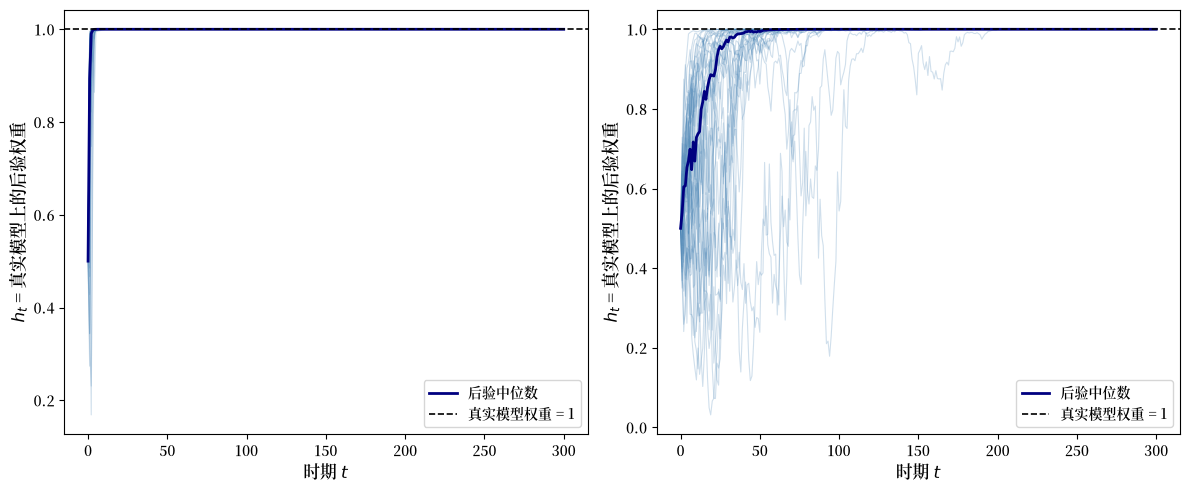

In [7]:
T = 300
h0 = 0.5     # 扩散先验
n_paths = 40
σ_p = 0.4

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 不同的简约形式
p_bar_true, p_bar_alt = 2.0, 1.2
h_paths = simulate_bayesian_learning(p_bar_true, p_bar_alt, σ_p, T, h0, n_paths)
plot_bayesian_learning(h_paths, p_bar_true, p_bar_alt, axes[0])

# 相似的简约形式
p_bar_true, p_bar_alt = 2.0, 1.8
h_paths_hard = simulate_bayesian_learning(
    p_bar_true, p_bar_alt, σ_p, T, h0, n_paths
)
plot_bayesian_learning(h_paths_hard, p_bar_true, p_bar_alt, axes[1])

plt.tight_layout()
plt.show()

在两个面板中，真实模型上的后验权重都以概率一收敛到 1，尽管当两个价格分布相似时（右面板）收敛较慢。

### 价格预期 vs. 理性预期

我们现在验证观察者的价格预期收敛到理性预期分布 $g(p \mid \bar\mu)$。

我们使用上面"难以学习"例子的参数化（$\bar{p}_{\text{true}} = 2.0$，$\bar{p}_{\text{alt}} = 1.8$，$\sigma_p = 0.4$），扩展到 $T = 1{,}000$ 个时期，使用单条模拟路径和先验 $h_0 = 0.5$

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


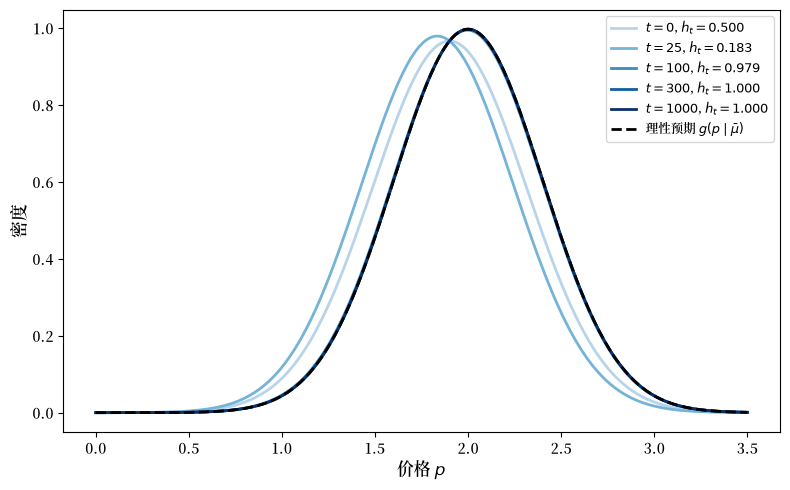

In [8]:
def price_expectation(h_t, p_bar_true, p_bar_alt, σ_p, p_grid):
    """返回后验权重 h_t 处的预测价格密度。"""
    return (
        h_t * norm.pdf(p_grid, loc=p_bar_true, scale=σ_p)
        + (1 - h_t) * norm.pdf(p_grid, loc=p_bar_alt, scale=σ_p)
    )


p_bar_true, p_bar_alt = 2.0, 1.8
σ_p = 0.4
n_paths = 1
T_long = 1000

h_paths_long = simulate_bayesian_learning(
    p_bar_true, p_bar_alt, σ_p, T_long, h0=0.5, n_paths=n_paths, seed=7
)

p_grid = np.linspace(0.0, 3.5, 300)
re_density = norm.pdf(p_grid, loc=p_bar_true, scale=σ_p)

fig, ax = plt.subplots(figsize=(8, 5))
snapshots = [0, 25, 100, 300, 1000]
palette   = plt.cm.Blues(np.linspace(0.3, 1.0, len(snapshots)))

for t_snap, col in zip(snapshots, palette):
    h_t = h_paths_long[0, t_snap]
    dens = price_expectation(h_t, p_bar_true, p_bar_alt, σ_p, p_grid)
    ax.plot(
        p_grid,
        dens,
        color=col,
        lw=2,
        label=rf"$t = {t_snap}$, $h_t = {h_t:.3f}$",
    )

ax.plot(p_grid, re_density, "k--", lw=2,
        label=r"理性预期 $g(p \mid \bar{\mu})$")
ax.set_xlabel("价格 $p$", fontsize=12)
ax.set_ylabel("密度", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

预测密度序列（蓝色的深浅）随着经验的累积收敛到理性预期密度（黑色虚线）。

这说明了 {prf:ref}`ime_theorem_bayesian_convergence`。

我们现在可以通过考察一个学到了简约形式但没有学到底层结构的例子来使这一点更加尖锐。

(km_extension_nonidentification)=
### 学到简约形式而不识别结构

这个收敛结果特别引人注目，因为即使底层**结构** $\lambda$ *无法*由价格*识别*，观察者也会收敛到*理性预期*。

为了说明这一点，考虑一个有*三个*可能结构 $\lambda^{(1)}, \lambda^{(2)}, \lambda^{(3)}$ 但只有*两个*简约形式 $\mu_1 = \{\lambda^{(1)}, \lambda^{(2)}\}$ 和 $\mu_2 = \{\lambda^{(3)}\}$ 的情形（因为 $\lambda^{(1)}$ 和 $\lambda^{(2)}$ 产生相同的价格分布）。

我们继续使用难以学习的参数化，因此三个结构的价格均值为 $\bar{p}_1 = \bar{p}_2 = 2.0$ 和 $\bar{p}_3 = 1.8$，共同标准差 $\sigma_p = 0.4$，均匀先验 $h_0 = (1/3, 1/3, 1/3)$，以及 $30$ 条路径上的 $T = 400$ 个时期。

真实结构是 $\lambda^{(1)}$。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


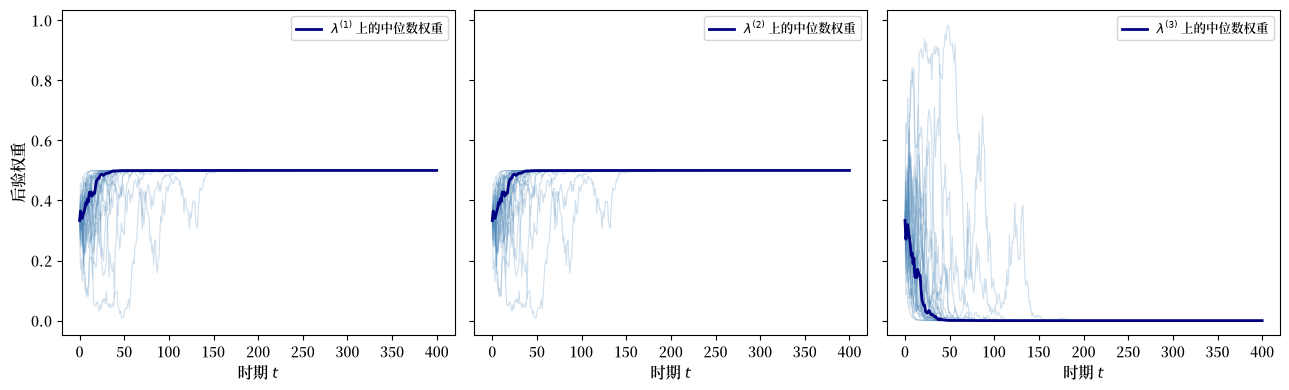

In [9]:
def simulate_learning_3struct(
    T, h0_vec, p_bar_vec, σ_p, true_idx, n_paths, seed=0
):
    """模拟具有三个结构和两个简约形式的学习。"""
    rng = np.random.default_rng(seed)
    h_paths = np.zeros((n_paths, T + 1, 3))
    h_paths[:, 0, :] = h0_vec

    for path in range(n_paths):
        h = np.array(h0_vec, dtype=float)
        prices = rng.normal(p_bar_vec[true_idx], σ_p, size=T)
        for t, p in enumerate(prices):
            likelihoods = norm.pdf(p, loc=p_bar_vec, scale=σ_p)
            h = h * likelihoods
            h /= h.sum()
            h_paths[path, t + 1, :] = h

    return h_paths


# 结构 0 和 1 共享相同的简约形式
p_bar_vec = np.array([2.0, 2.0, 1.8])
h0_vec = np.array([1 / 3, 1 / 3, 1 / 3])
σ_p = 0.4
T = 400
true_idx = 0     # 结构 0 与结构 1 在观测上等价

h_paths_3 = simulate_learning_3struct(
    T, h0_vec, p_bar_vec, σ_p, true_idx, n_paths=30
)
t_grid = np.arange(T + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
struct_labels = [
    r"$\lambda^{(1)}$",
    r"$\lambda^{(2)}$",
    r"$\lambda^{(3)}$",
]

for k, (ax, label) in enumerate(zip(axes, struct_labels)):
    for path in h_paths_3:
        ax.plot(t_grid, path[:, k], alpha=0.25, lw=0.8, color="steelblue")
    ax.plot(t_grid, np.median(h_paths_3[:, :, k], axis=0),
            color="navy", lw=2, label=f"{label} 上的中位数权重")
    ax.set_xlabel("时期 $t$", fontsize=11)
    ax.legend(fontsize=9)

axes[0].set_ylabel("后验权重", fontsize=11)
plt.tight_layout()
plt.show()

观察者以概率一正确地排除了 $\lambda^{(3)}$（错误的简约形式），但无法区分 $\lambda^{(1)}$ 和 $\lambda^{(2)}$，因为它们产生相同的价格分布。

尽管如此，观察者的**价格预期**收敛到理性预期，因为两个结构都隐含相同的简约形式 $\bar\mu$。


## 练习

```{exercise}
:label: km_ex1

**CARA 投资组合效用与股票市场解释。**

考虑一个两状态经济（$a_1 = 2$，$a_2 = 0.5$），其中知情代理人对投资组合财富具有 **CARA**（常绝对风险厌恶）偏好：

$$
u(W) = -e^{-\gamma W}, \quad W = x_2 + \bar{a}\, x_1.
$$

代理人选择 $x_1$ 以最大化

$$
q\,u(W_1) + (1-q)\,u(W_2), \quad W_s = w - p\,x_1 + a_s\,x_1,
$$

受预算约束 $p\,x_1 + x_2 = w$ 的约束。

商品 1 的总供给为 $X_1 = 1$。

1. 推导知情代理人最优 $x_1$ 的一阶条件。

1. 使用市场出清条件 $x_1 = 1$（知情代理人吸收全部供给）来得到均衡价格 $p^*(q)$ 的一个隐式方程，并对 $q \in (0,1)$ 和若干 $\gamma$ 值进行数值求解。

1. *解析地*证明 $p^*(q)$ 具有闭式解

   $$
   p^*(q) = \frac{a_2 + R(q,\gamma)\, a_1}{1 + R(q,\gamma)},
   \qquad R(q,\gamma) = \frac{q}{1-q}\, e^{-\gamma(a_1-a_2)},
   $$

   并验证 $p^*(q)$ 在 $q$ 上是严格递增的。
```

```{solution-start} km_ex1
:class: dropdown
```

对于一阶条件，定义 $W_s = w + (a_s - p)\,x_1$，其中 $s = 1, 2$。

那么 FOC 为

$$
q\,(a_1 - p)\,\gamma\, e^{-\gamma W_1}
= (1-q)\,(p - a_2)\,\gamma\, e^{-\gamma W_2},
$$

或等价地（除以 $\gamma$ 并重新排列）

$$
q\,(a_1 - p)\, e^{-\gamma(a_1-p) x_1}
  = (1-q)\,(p - a_2)\, e^{\gamma(p-a_2) x_1}.
$$

设 $x_1 = 1$（知情代理人吸收全部供给），这变成关于 $p$ 的标量求根问题：

$$
F(p;\,q,\gamma) \equiv
  q\,(a_1-p)\,e^{-\gamma(a_1-p)} - (1-q)\,(p-a_2)\,e^{\gamma(p-a_2)} = 0.
$$

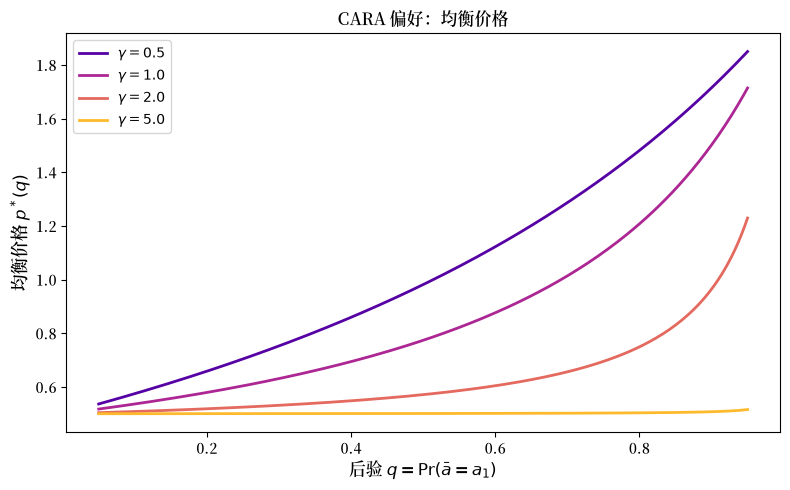

In [10]:
from scipy.optimize import brentq

def F_cara(p, q, a1, a2, γ, x1=1.0):
    """CARA 均衡条件的残差。"""
    return (q * (a1 - p) * np.exp(-γ * (a1 - p) * x1)
            - (1 - q) * (p - a2) * np.exp(γ * (p - a2) * x1))

a1, a2 = 2.0, 0.5
q_grid = np.linspace(0.05, 0.95, 200)
γ_values = [0.5, 1.0, 2.0, 5.0]
colors_sol = plt.cm.plasma(np.linspace(0.15, 0.85, len(γ_values)))

fig, ax = plt.subplots(figsize=(8, 5))
for γ, color in zip(γ_values, colors_sol):
    p_eq = [brentq(F_cara, a2, a1,
                   args=(q, a1, a2, γ))
            for q in q_grid]
    ax.plot(q_grid, p_eq, lw=2, color=color,
            label=rf"$\gamma = {γ}$")

ax.set_xlabel(r"后验 $q = \Pr(\bar a = a_1)$", fontsize=12)
ax.set_ylabel("均衡价格 $p^*(q)$", fontsize=12)
ax.set_title("CARA 偏好：均衡价格", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

对于每个 $\gamma > 0$，价格在 $q$ 上都是严格递增的。

对于闭式解，从 $x_1 = 1$ 处的 FOC 出发，两边除以 $(a_1 - p)(p - a_2)$，并合并指数项：

$$
\frac{q\,(a_1 - p)}{(1-q)\,(p - a_2)} = e^{\gamma(a_1 - a_2)}.
$$

重新排列得到

$$
\frac{p - a_2}{a_1 - p} = \frac{q}{1-q}\, e^{-\gamma(a_1 - a_2)}
\equiv R(q,\gamma),
$$

求解所得的关于 $p$ 的线性方程得到

$$
p^*(q) = \frac{a_2 + R(q,\gamma)\, a_1}{1 + R(q,\gamma)}.
$$

由于 $R(q,\gamma)$ 在 $q$ 上严格递增，且 $dp^*/dR = (a_1 - a_2)/(1 + R)^2 > 0$，因此均衡价格 $p^*(q)$ 在 $q$ 上严格递增。

这个练习使用了 {cite:t}`kihlstrom_mirman1975` 所强调的股票市场解释。

投资组合财富为 $W = x_2 + \bar{a}\, x_1$，因此 $a x_1$ 和 $x_2$ 在每个状态中是完全替代品。

因此 $u(a x_1, x_2)$ 两个参数之间的替代弹性是无穷大，对应于 {prf:ref}`ime_theorem_invertibility_conditions` 中 $\sigma > 1$ 的一侧。

不同之处在于，这个例子不是该定理所分析的完整均衡模型，而是一个具有单一知情代理人和固定风险资产供给的局部均衡模型。

```{solution-end}
```

```{exercise}
:label: km_ex2

在贝叶斯学习模拟中，收敛到理性预期的速度由两个简约形式之间的 **Kullback-Leibler 散度**决定。

对于两个均值为 $\bar{p}_1$ 和 $\bar{p}_2$ 且共同方差为 $\sigma_p^2$ 的正态分布，从 $g(\cdot \mid \mu_1)$ 到 $g(\cdot \mid \mu_2)$ 的 KL 散度 $D_{KL}(\mu_1 \| \mu_2)$ 为

$$
D_{KL}(\mu_1 \| \mu_2) = \frac{(\bar{p}_1 - \bar{p}_2)^2}{2\sigma_p^2},
$$

在方差相等的情况下，它关于两个均值是对称的。

1. 对于"容易的"情形（$\bar{p}_1 = 2.0$，$\bar{p}_2 = 1.2$）和"困难的"情形（$\bar{p}_1 = 2.0$，$\bar{p}_2 = 1.8$），计算 $\sigma_p = 0.4$ 时的 $D_{KL}$。

1. 用 $n=100$ 条路径重新运行本讲中两种情形的模拟。对每条路径计算 $h_t \geq 0.99$ 的第一个时期 $T_{0.99}$。绘制两种情形下 $T_{0.99}$ 的直方图。

1. 中位数 $T_{0.99}$ 如何随 $D_{KL}$ 缩放？数值验证对于某个常数 $C$，大致有 $T_{0.99} \approx C / D_{KL}$。
```

```{solution-start} km_ex2
:class: dropdown
```

这是一个解法：

Easy case: D_KL = 2.0000
Hard case: D_KL = 0.1250


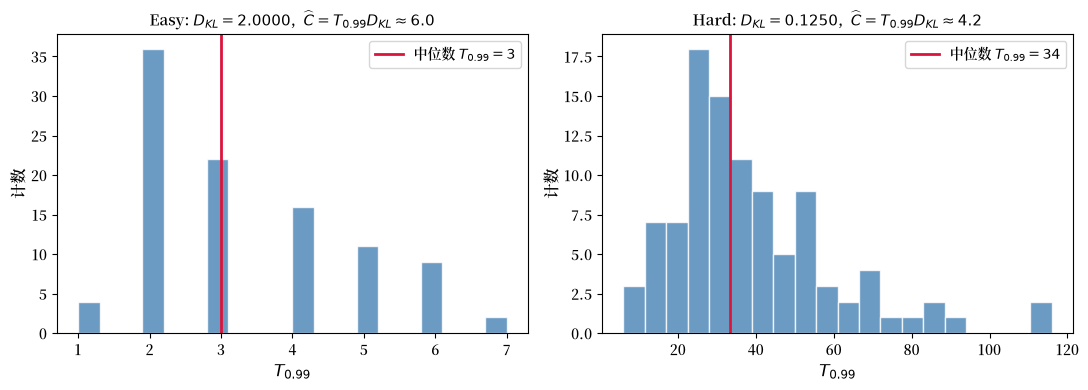

In [11]:
σ_p = 0.4

def kl_normal(p1, p2, σ):
    """返回 N(p1, σ^2) 和 N(p2, σ^2) 的 KL 散度。"""
    return (p1 - p2)**2 / (2 * σ**2)

cases = [("Easy",  2.0, 1.2), ("Hard", 2.0, 1.8)]
for name, p1, p2 in cases:
    kl = kl_normal(p1, p2, σ_p)
    print(f"{name} case: D_KL = {kl:.4f}")

n_paths = 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, p1, p2) in zip(axes, cases):
    kl = kl_normal(p1, p2, σ_p)
    paths = simulate_bayesian_learning(p1, p2, σ_p, T=2000,
                                       h0=0.5, n_paths=n_paths, seed=42)
    # 后验 >= 0.99 的第一个时期
    T99 = []
    for path in paths:
        idx = np.where(path >= 0.99)[0]
        T99.append(idx[0] if len(idx) > 0 else 2001)

    median_T = np.median(T99)
    ax.hist(T99, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(median_T, color="crimson", lw=2,
               label=fr"中位数 $T_{{0.99}} = {median_T:.0f}$")
    ax.set_title(
        f"{name}: $D_{{KL}} = {kl:.4f}$,  "
        fr"$\widehat C = T_{{0.99}} D_{{KL}} \approx {median_T * kl:.1f}$",
        fontsize=11 
    )
    ax.set_xlabel(r"$T_{0.99}$", fontsize=12)
    ax.set_ylabel("计数", fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

中位数 $T_{0.99}$ 大致按 $C/D_{KL}$ 缩放，证实了当两个简约形式更容易区分时（大的 $D_{KL}$）学习更快。

```{solution-end}
```

```{exercise}
:label: km_ex3

{prf:ref}`ime_theorem_bayesian_convergence` 要求先验对真实简约形式类 $\bar\mu$ 赋予正概率，等价地对某个产生真实价格分布 $g(\cdot \mid \bar\mu)$ 的结构赋予正概率。

在这个练习中，真实简约形式本身被排除在先验支持之外，因此我们研究当先验中没有模型产生真实价格分布时会发生什么。

从 $N(2.0, 0.4^2)$ 模拟 $T = 1,000$ 个时期的价格，但使用一个对两个*错误*模型 $N(1.5, 0.4^2)$ 和 $N(2.3, 0.4^2)$ 赋予相等权重的先验。

绘制每个模型随时间变化的后验权重。

讨论你的发现。
```

```{solution-start} km_ex3
:class: dropdown
```

这是一个解法：

KL(true || N(1.5, σ^2)) = 0.7812
KL(true || N(2.3, σ^2)) = 0.2812
True mean: 2.0
Predictive mean at T=1000: 2.3000
Closer misspecified mean: 2.3


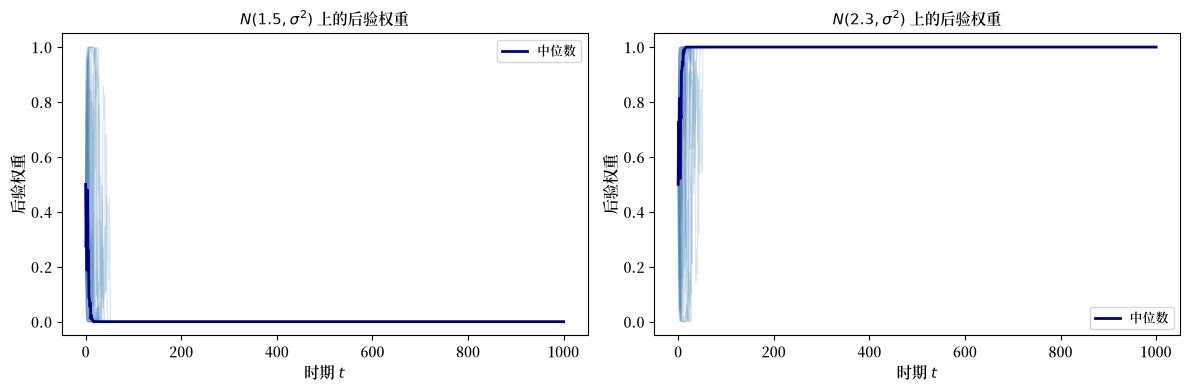

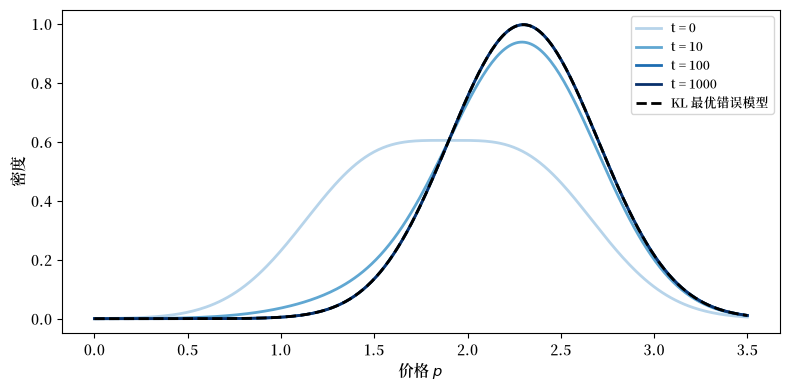

True mean: 2.0
Predictive mean at T=1000: 2.3000
Closer misspecified mean: 2.3


In [12]:
def simulate_misspecified(
    T, p_bar_true, p_bar_wrong, σ_p, h0, n_paths, seed=0
):
    """在错误设定的双模型先验下模拟学习。"""
    rng = np.random.default_rng(seed)
    h_paths = np.zeros((n_paths, T + 1, 2))
    h_paths[:, 0, :] = h0

    for path in range(n_paths):
        h = np.array(h0, dtype=float)
        prices = rng.normal(p_bar_true, σ_p, size=T)
        for t, price in enumerate(prices):
            likes = norm.pdf(price, loc=p_bar_wrong, scale=σ_p)
            h = h * likes
            h /= h.sum()
            h_paths[path, t + 1, :] = h

    return h_paths


def predictive_density(weights, means, σ_p, p_grid):
    """返回当前后验权重下的预测密度。"""
    density = np.zeros_like(p_grid)
    for weight, mean in zip(weights, means):
        density += weight * norm.pdf(p_grid, loc=mean, scale=σ_p)
    return density


T = 1000
p_true = 2.0
p_wrong = np.array([1.5, 2.3])
σ_p = 0.4
h0 = np.array([0.5, 0.5])
n_paths = 30

h_misspec = simulate_misspecified(T, p_true, p_wrong, σ_p, h0, n_paths)

kl_vals = (p_true - p_wrong)**2 / (2 * σ_p**2)
for mean, kl in zip(p_wrong, kl_vals):
    print(f"KL(true || N({mean:.1f}, σ^2)) = {kl:.4f}")

t_grid = np.arange(T + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [r"$N(1.5, \sigma^2)$", r"$N(2.3, \sigma^2)$"]
for ax, k, label in zip(axes, [0, 1], labels):
    for path in h_misspec:
        ax.plot(t_grid, path[:, k], alpha=0.2, lw=0.8, color="steelblue")
    ax.plot(t_grid, np.median(h_misspec[:, :, k], axis=0),
            color="navy", lw=2, label="中位数")
    ax.set_title(f"{label} 上的后验权重", fontsize=11)
    ax.set_xlabel("时期 $t$", fontsize=11)
    ax.set_ylabel("后验权重", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 沿后验中位数路径的预测密度和均值
median_path = np.median(h_misspec, axis=0)
p_grid = np.linspace(0.0, 3.5, 300)
closer_idx = np.argmin(kl_vals)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Blues(np.linspace(0.3, 1.0, 4))
for t_snap, color in zip([0, 10, 100, T], colors):
    dens = predictive_density(median_path[t_snap], p_wrong, σ_p, p_grid)
    ax.plot(p_grid, dens, color=color, lw=2, label=f"t = {t_snap}")

ax.plot(
    p_grid,
    norm.pdf(p_grid, loc=p_wrong[closer_idx], scale=σ_p),
    "k--",
    lw=2,
    label="KL 最优错误模型",
)
ax.set_xlabel("价格 $p$", fontsize=11)
ax.set_ylabel("密度", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pred_mean = np.median(
    h_misspec[:, :, 0] * p_wrong[0] + h_misspec[:, :, 1] * p_wrong[1], axis=0
)
print(f"True mean: {p_true}")
print(f"Predictive mean at T={T}: {pred_mean[-1]:.4f}")
print(f"Closer misspecified mean: {p_wrong[np.argmin(kl_vals)]:.1f}")

这里

$$
D_{KL}\bigl(N(2.0, 0.4^2)\,\|\,N(2.3, 0.4^2)\bigr)
<
D_{KL}\bigl(N(2.0, 0.4^2)\,\|\,N(1.5, 0.4^2)\bigr),
$$

因此均值为 $2.3$ 的模型是两个错误模型中 KL 最优的近似，在模拟中后验权重集中于该模型。

后验几率是累积的{doc}`似然比 <likelihood_bayes>`。

如果我们比较两个错误的高斯模型 $f$ 和 $g$，那么在真实分布 $h$ 下，平均对数似然比满足

$$
\frac{1}{t} E_h[\log L_t] = K(h,g) - K(h,f).
$$

因此，如果 $f$ 在 KL 意义上比 $g$ 更接近 $h$，那么 $\log L_t$ 有正的漂移，后验几率会倾向于 $f$。

```{solution-end}
```